# Análise de Séries Temporais por Estado
Este notebook consolida as análises de RJ, SP e RS usando as séries interpoladas.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import os

# Função para carregar os dados interpolados

def carregar_interpolado(estado, categoria, periodicidade):
    pasta = f"Interpolado/{estado.upper()}/{periodicidade}/"
    nome_arquivo = f"{estado.upper()}_{categoria.upper()}.csv"
    caminho = os.path.join(pasta, nome_arquivo)
    df = pd.read_csv(caminho)
    df["Proj_Date"] = pd.to_datetime(df["Proj_Date"])
    return df

estados = ["RJ", "SP", "RS"]
categorias = ["FERRAGENS", "CONSTRUCAO_CIVIL", "MATERIAIS_ELETRICOS"]
periodicidades = ["Semanal", "Quinzenal"]

# Carregar todos os DataFrames em um dicionário
bases_interpoladas = {}
for estado in estados:
    for categoria in categorias:
        for periodicidade in periodicidades:
            chave = f"{estado.lower()}_{categoria.lower()}_{periodicidade.lower()}"
            bases_interpoladas[chave] = carregar_interpolado(estado, categoria, periodicidade)

## Overlay Semanal vs Quinzenal por Estado e Categoria

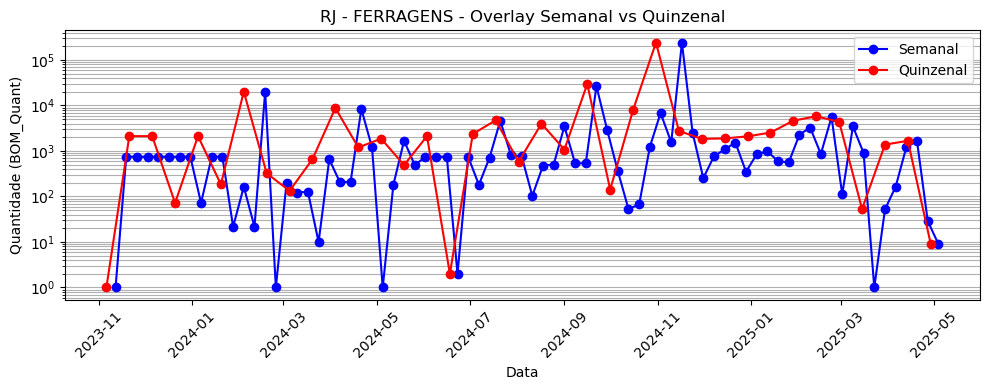

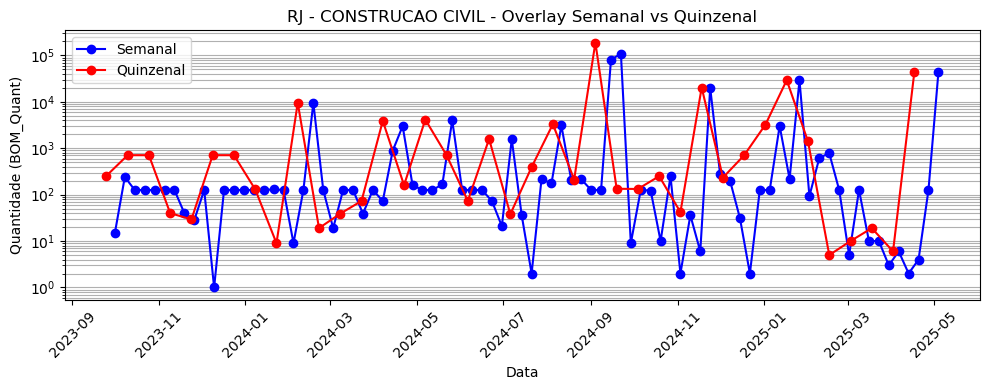

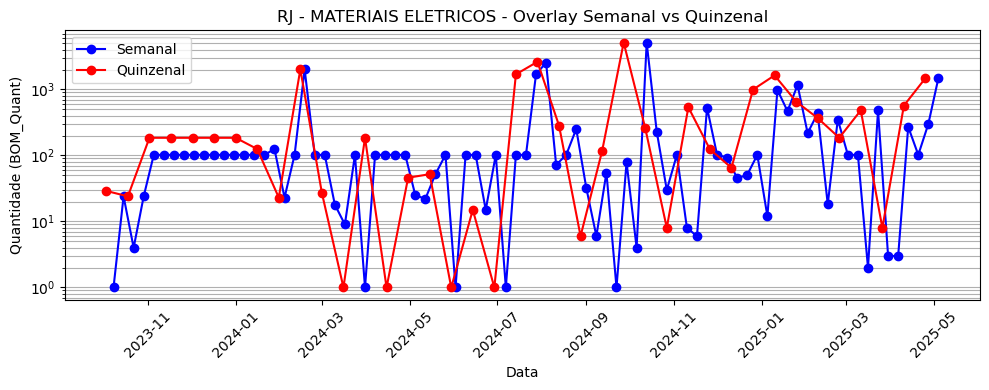

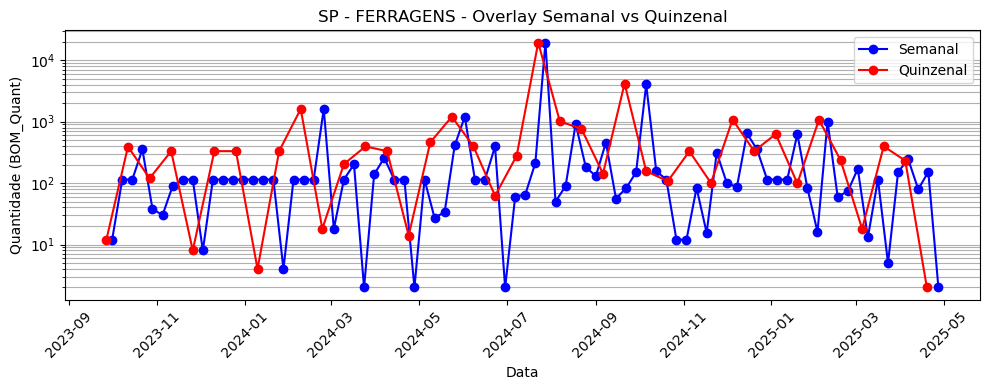

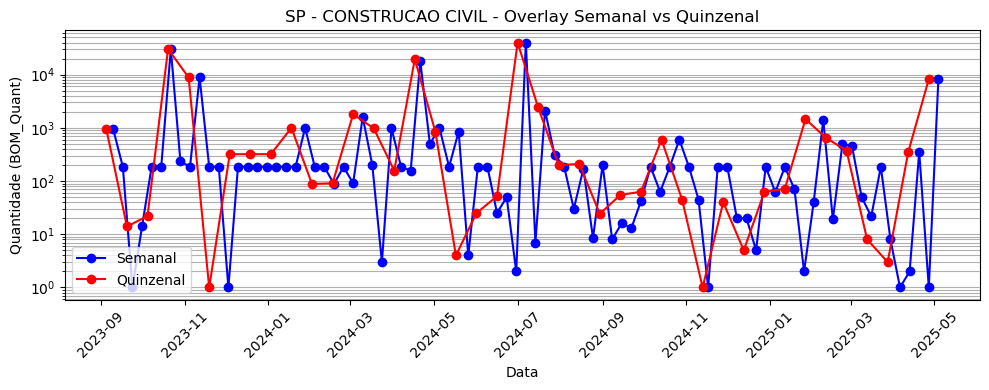

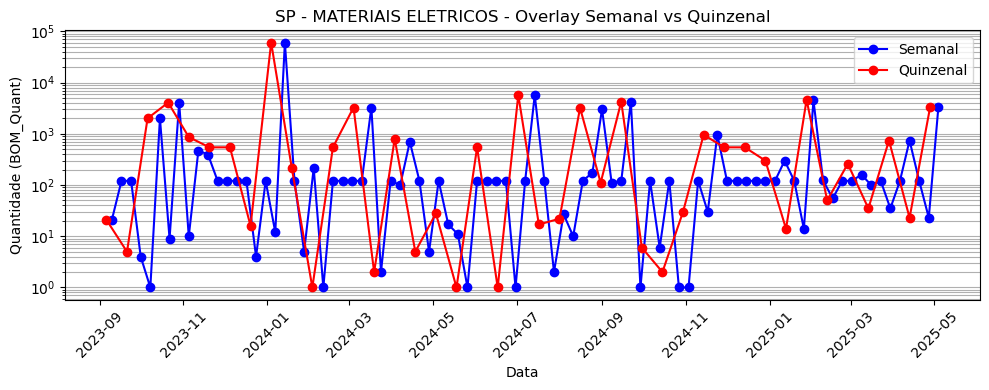

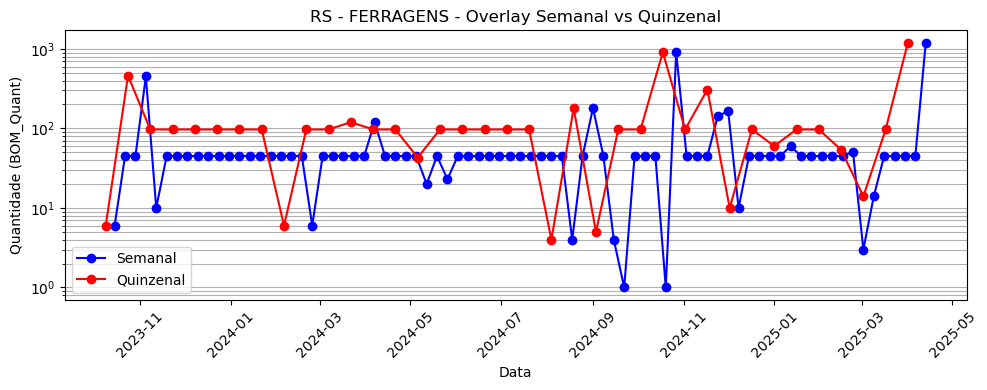

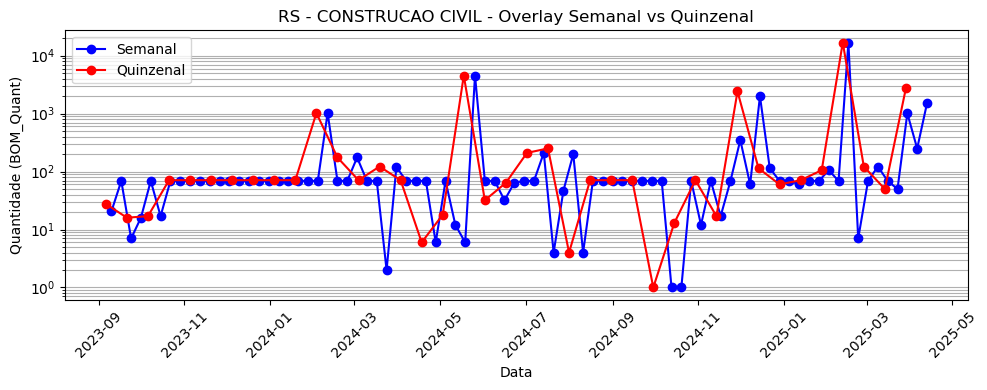

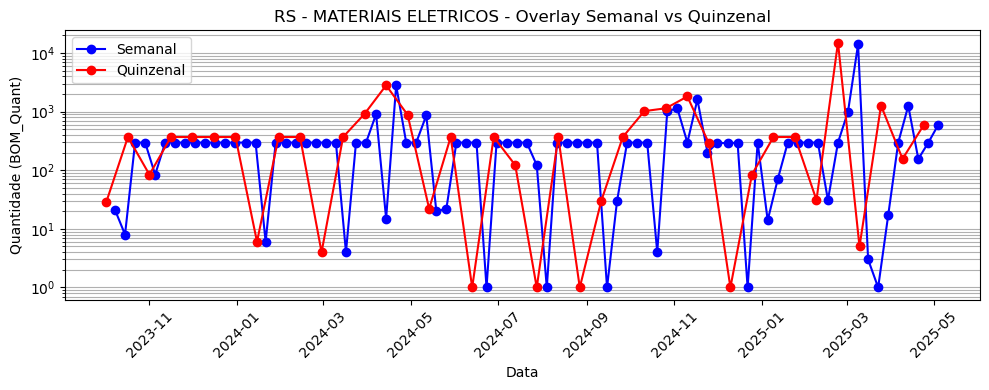

In [8]:
for estado in estados:
    for categoria in categorias:
        chave_sem = f"{estado.lower()}_{categoria.lower()}_semanal"
        chave_quin = f"{estado.lower()}_{categoria.lower()}_quinzenal"
        df_sem = bases_interpoladas[chave_sem]
        df_quin = bases_interpoladas[chave_quin]
        plt.figure(figsize=(10, 4))
        df_sem_plot = df_sem[df_sem["BOM_Quant"] > 0]
        df_quin_plot = df_quin[df_quin["BOM_Quant"] > 0]
        plt.plot(df_sem_plot["Proj_Date"], df_sem_plot["BOM_Quant"], marker='o', color='blue', label='Semanal')
        plt.plot(df_quin_plot["Proj_Date"], df_quin_plot["BOM_Quant"], marker='o', color='red', label='Quinzenal')
        plt.title(f"{estado} - {categoria.replace('_', ' ')} - Overlay Semanal vs Quinzenal")
        plt.xlabel("Data")
        plt.ylabel("Quantidade (BOM_Quant)")
        plt.yscale('log')
        plt.grid(True, which='both', axis='y')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## Overlay de Categorias por Estado (Semanal e Quinzenal)

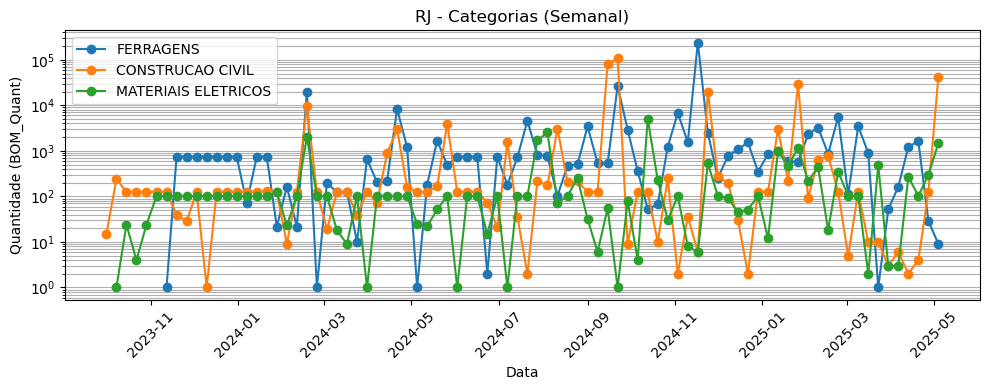

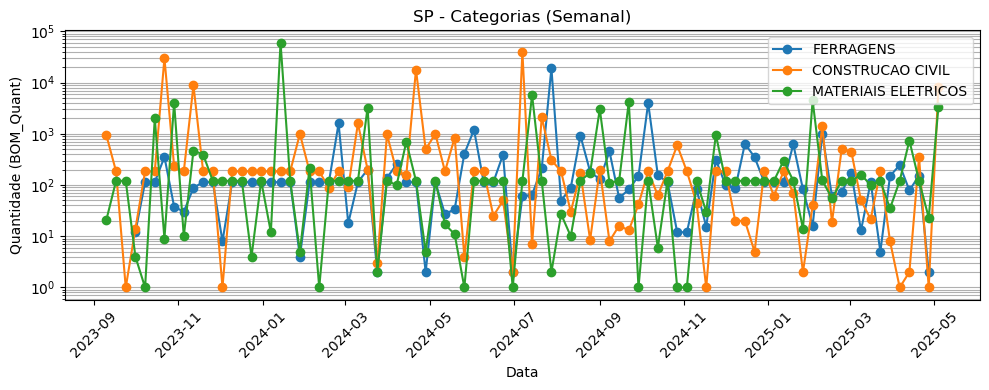

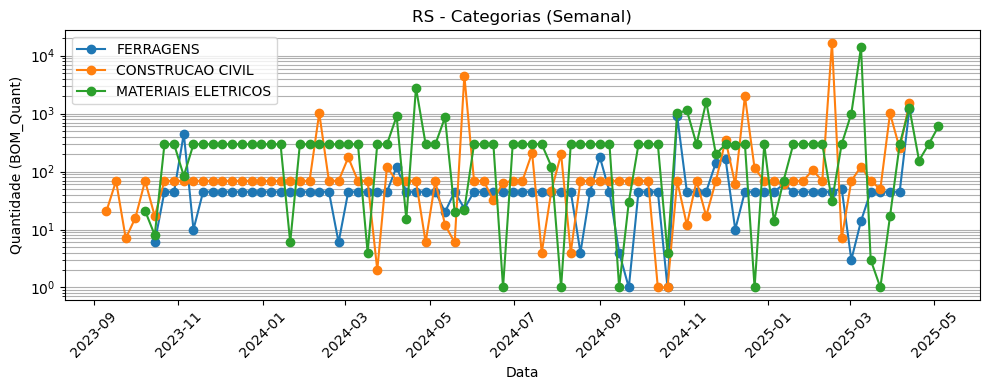

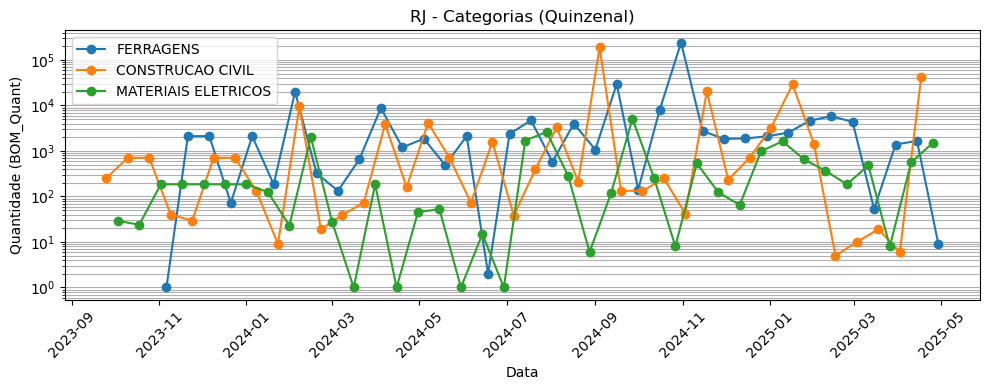

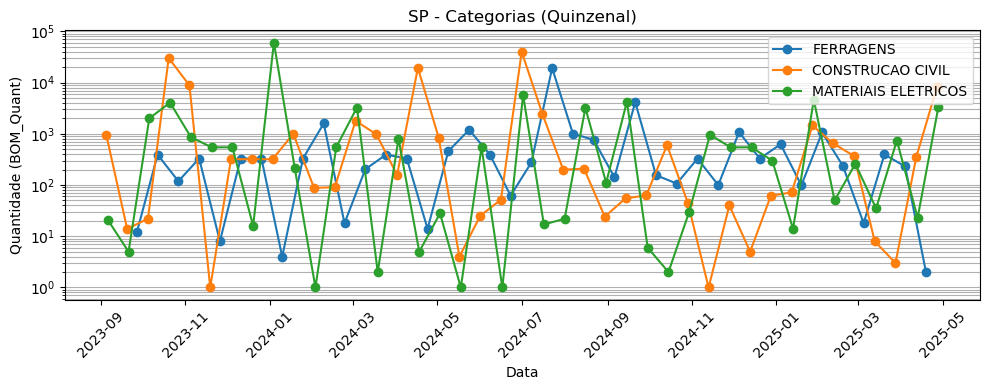

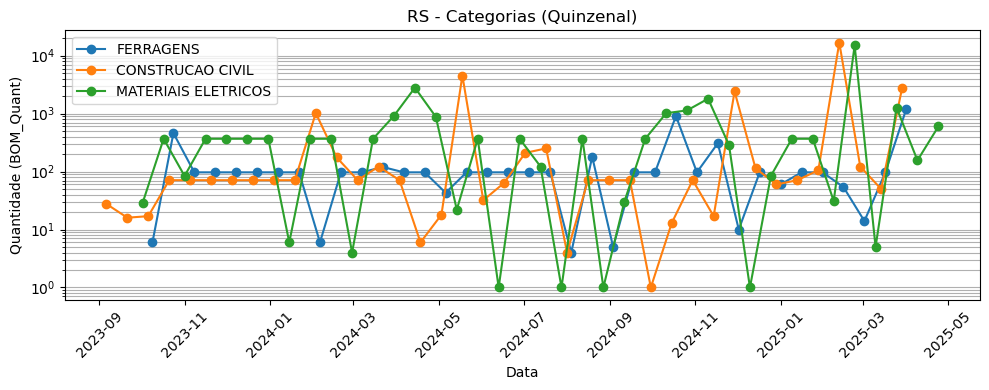

In [9]:
# Gráficos semanais por estado
for estado in estados:
    plt.figure(figsize=(10, 4))
    for categoria in categorias:
        chave = f"{estado.lower()}_{categoria.lower()}_semanal"
        df = bases_interpoladas[chave]
        df_plot = df[df["BOM_Quant"] > 0]
        plt.plot(df_plot["Proj_Date"], df_plot["BOM_Quant"], marker='o', label=categoria.replace("_", " "))
    plt.title(f"{estado} - Categorias (Semanal)")
    plt.xlabel("Data")
    plt.ylabel("Quantidade (BOM_Quant)")
    plt.yscale('log')
    plt.grid(True, which='both', axis='y')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Gráficos quinzenais por estado
for estado in estados:
    plt.figure(figsize=(10, 4))
    for categoria in categorias:
        chave = f"{estado.lower()}_{categoria.lower()}_quinzenal"
        df = bases_interpoladas[chave]
        df_plot = df[df["BOM_Quant"] > 0]
        plt.plot(df_plot["Proj_Date"], df_plot["BOM_Quant"], marker='o', label=categoria.replace("_", " "))
    plt.title(f"{estado} - Categorias (Quinzenal)")
    plt.xlabel("Data")
    plt.ylabel("Quantidade (BOM_Quant)")
    plt.yscale('log')
    plt.grid(True, which='both', axis='y')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Decomposição de Séries Temporais (Quinzenal)

In [10]:
def decompor_e_plotar(df, titulo):
    df = df.copy()
    df = df.set_index("Proj_Date").asfreq("2W-MON")
    df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)
    decomposicao = seasonal_decompose(df["BOM_Quant"], model="additive", period=2)
    plt.figure(figsize=(12, 8))
    plt.suptitle(titulo, fontsize=14)
    decomposicao.observed.plot(ax=plt.subplot(411), title='Observado')
    decomposicao.trend.plot(ax=plt.subplot(412), title='Tendência')
    decomposicao.seasonal.plot(ax=plt.subplot(413), title='Sazonalidade')
    decomposicao.resid.plot(ax=plt.subplot(414), title='Resíduo')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


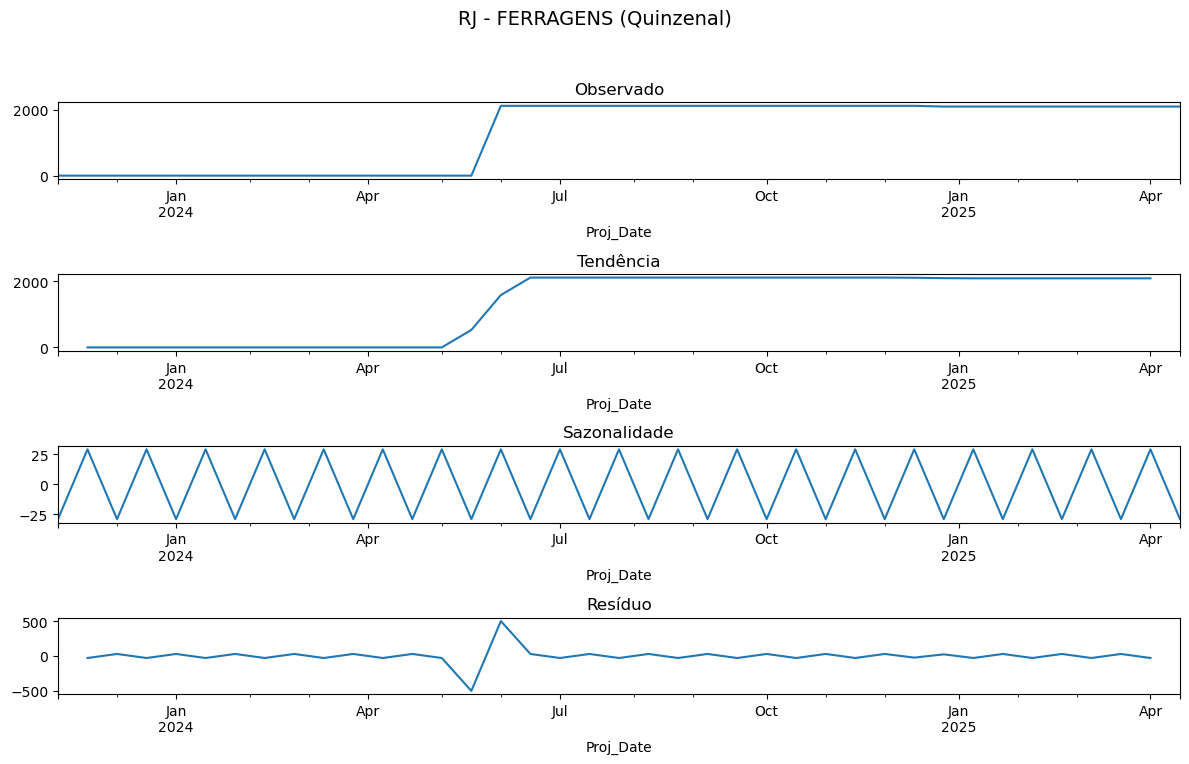

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


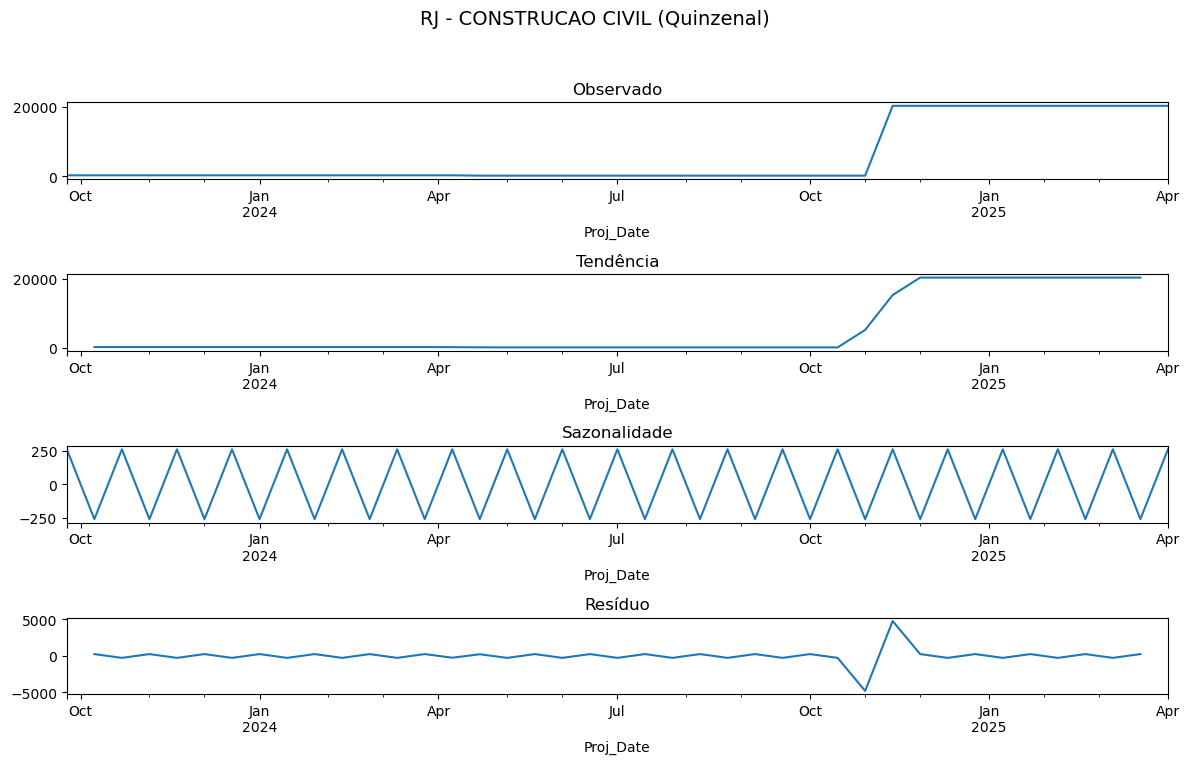

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


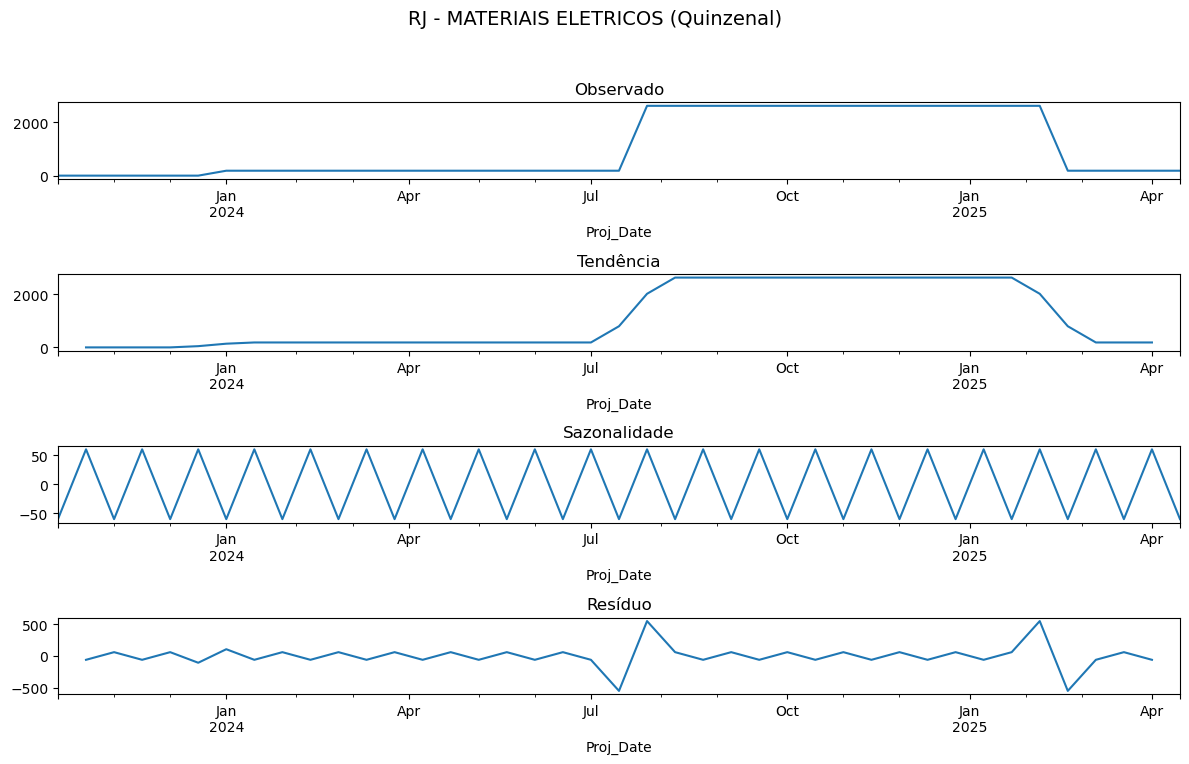

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


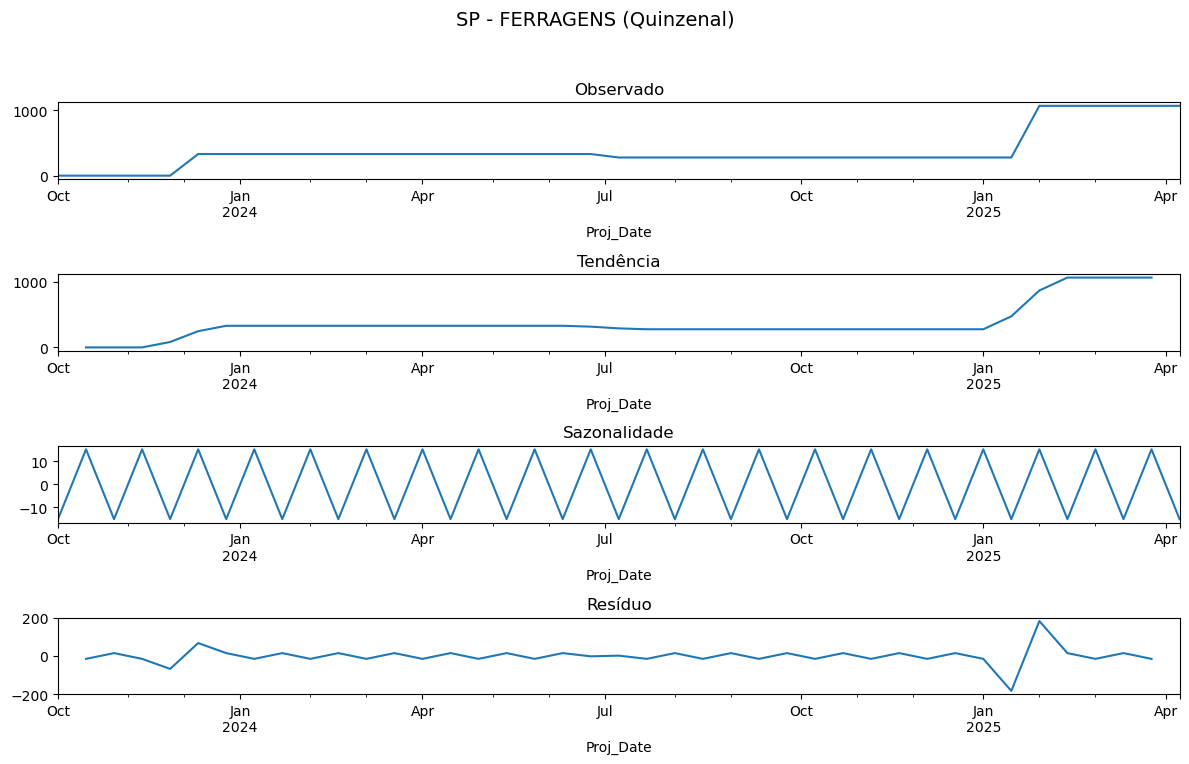

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


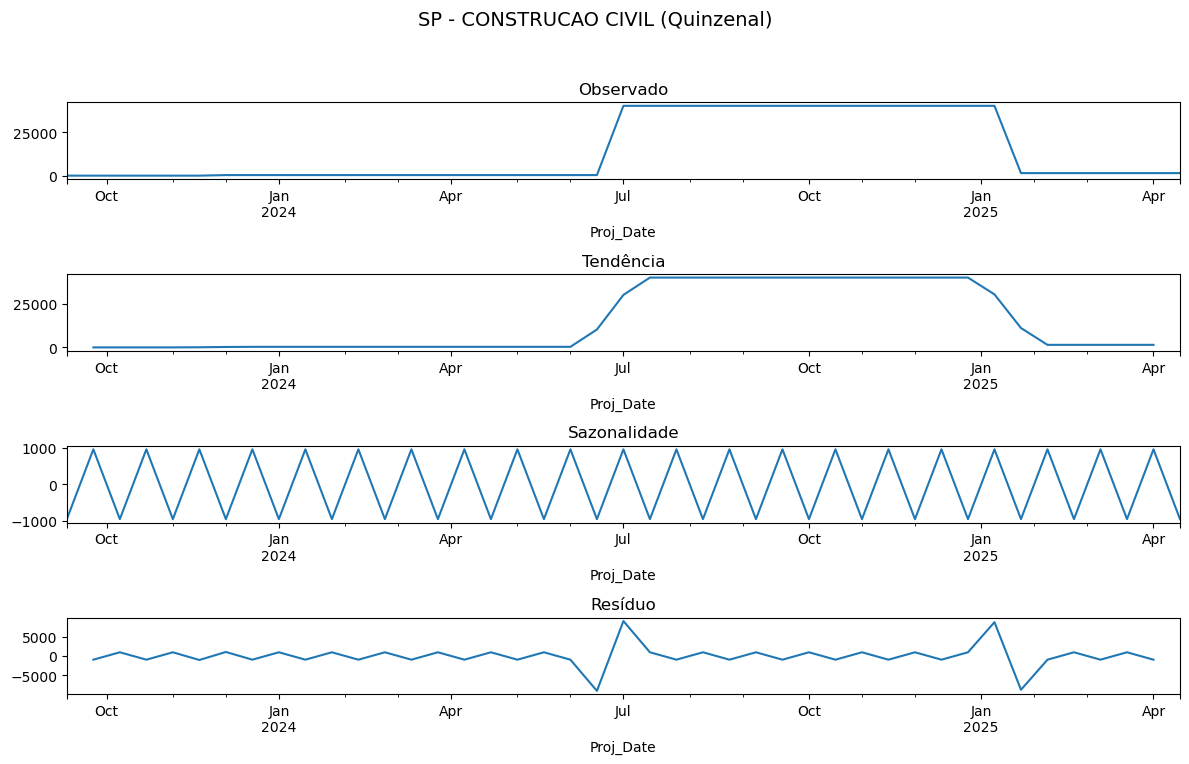

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


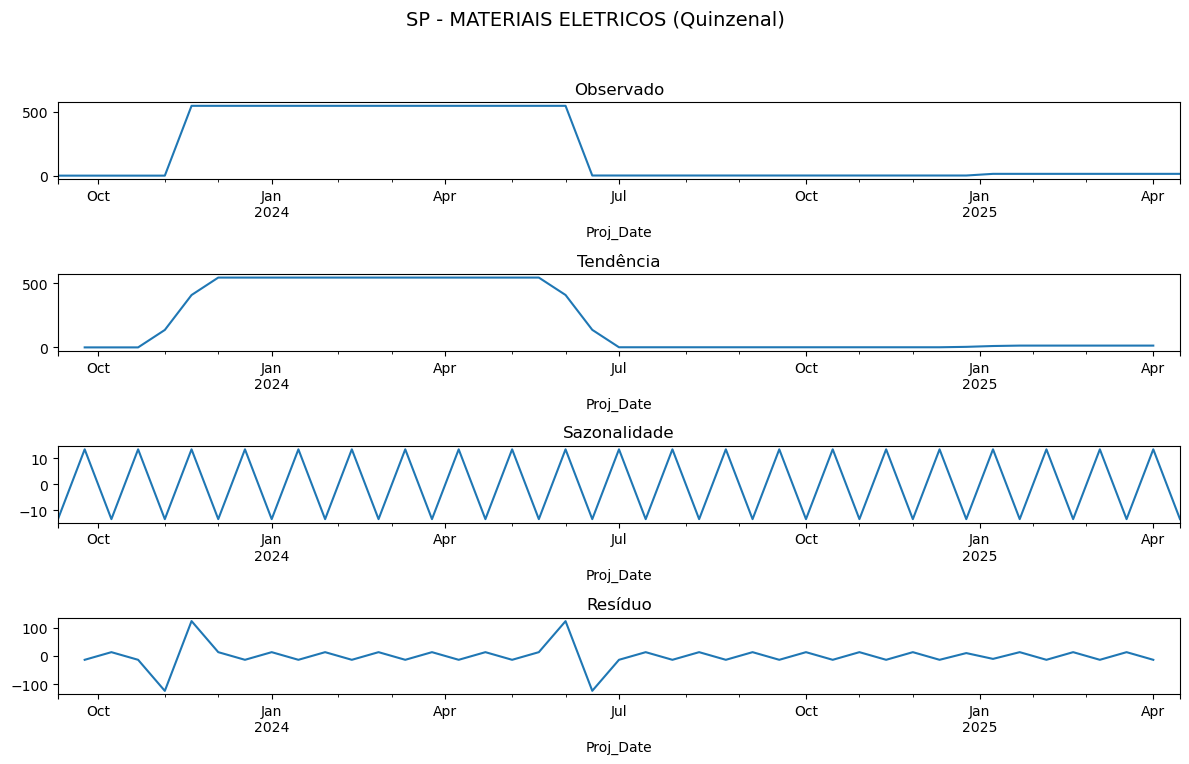

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


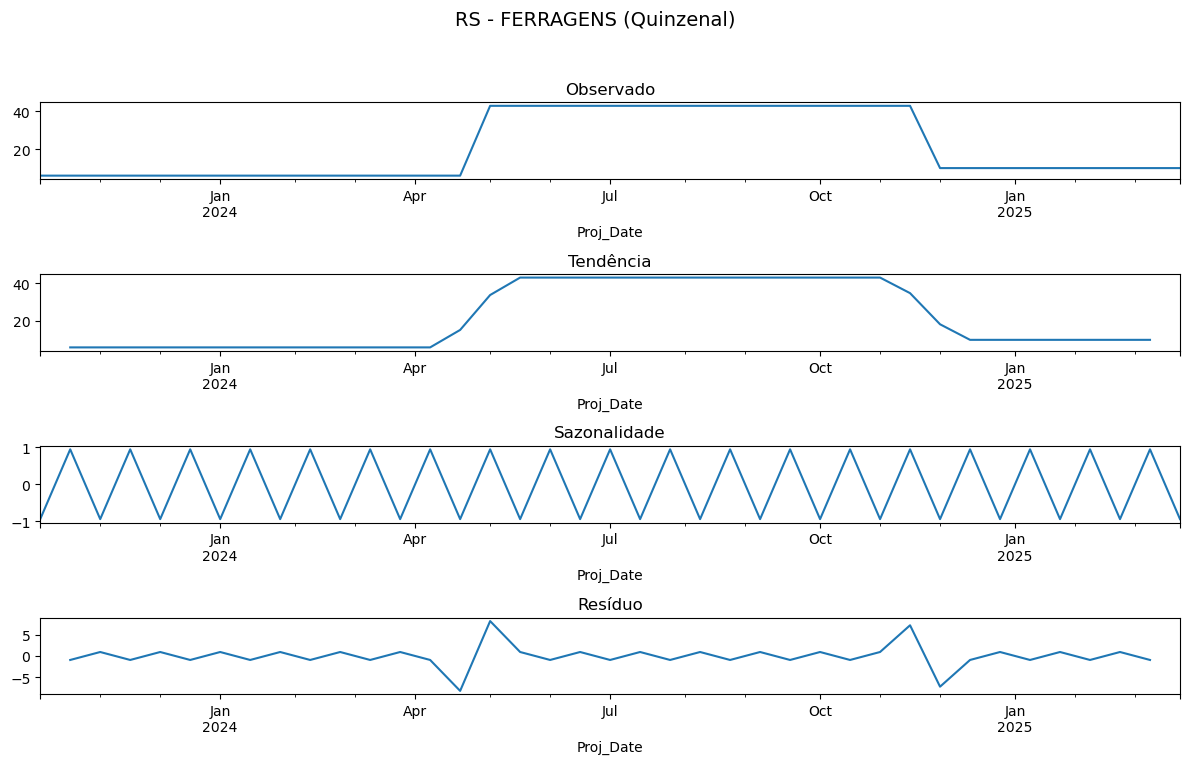

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


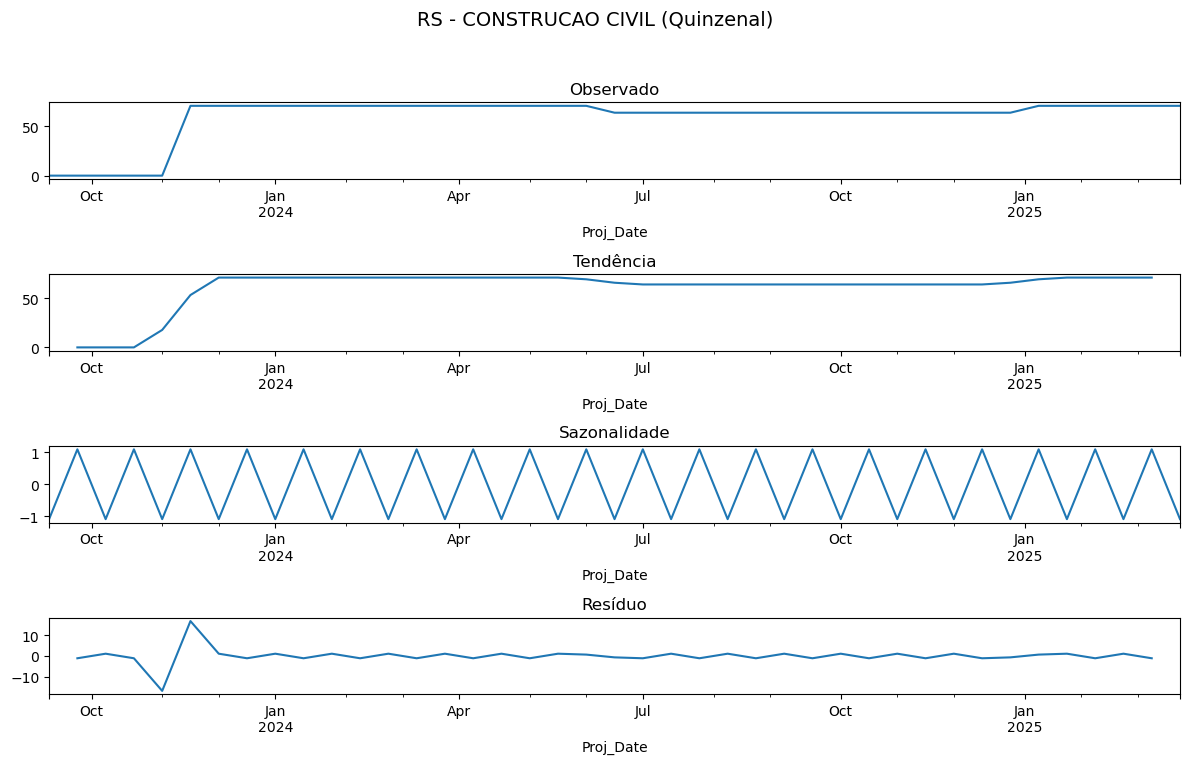

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


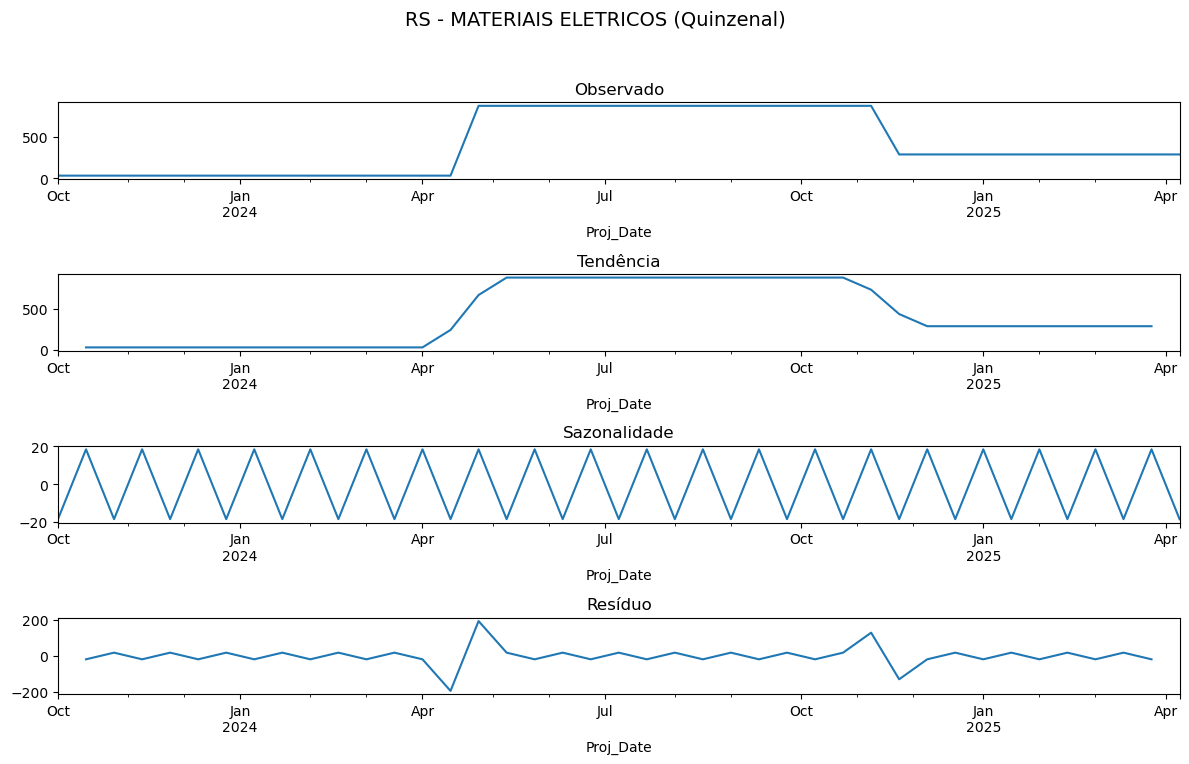

In [11]:
# Decomposição por categoria quinzenal
for estado in estados:
    for categoria in categorias:
        chave = f"{estado.lower()}_{categoria.lower()}_quinzenal"
        df = bases_interpoladas[chave]
        titulo = f"{estado} - {categoria.replace('_', ' ')} (Quinzenal)"
        decompor_e_plotar(df, titulo)

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


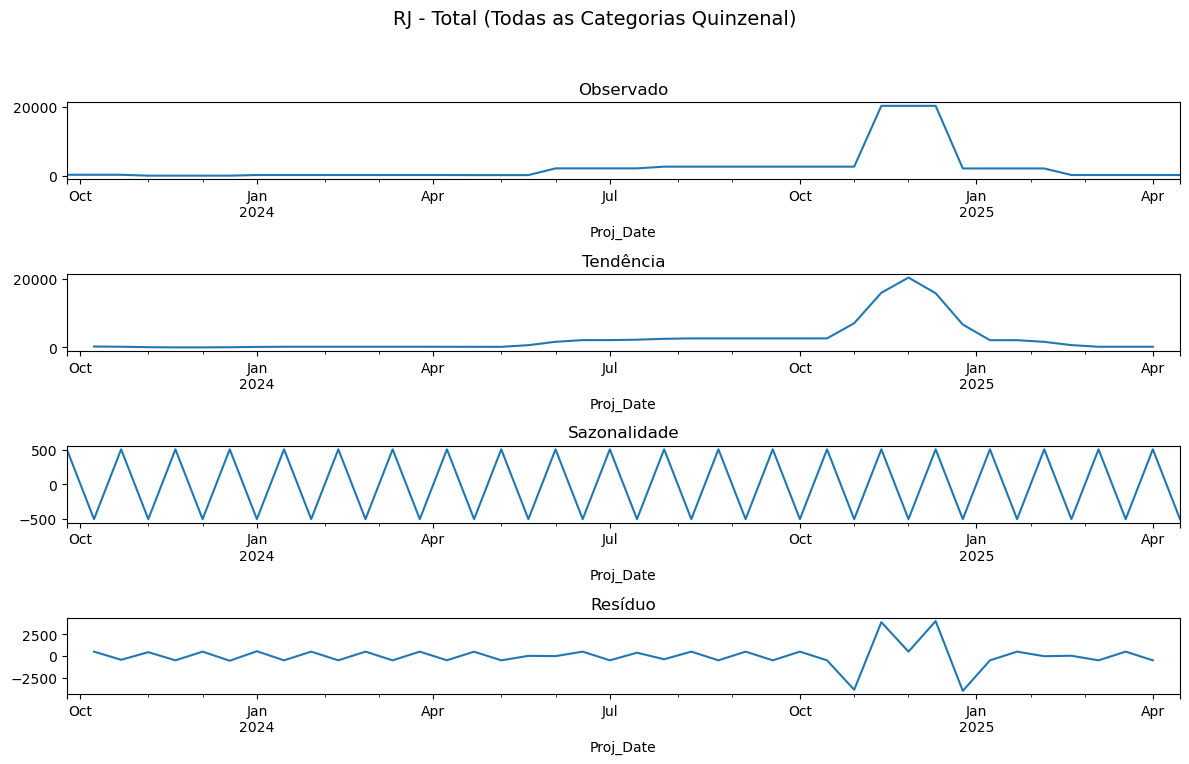

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


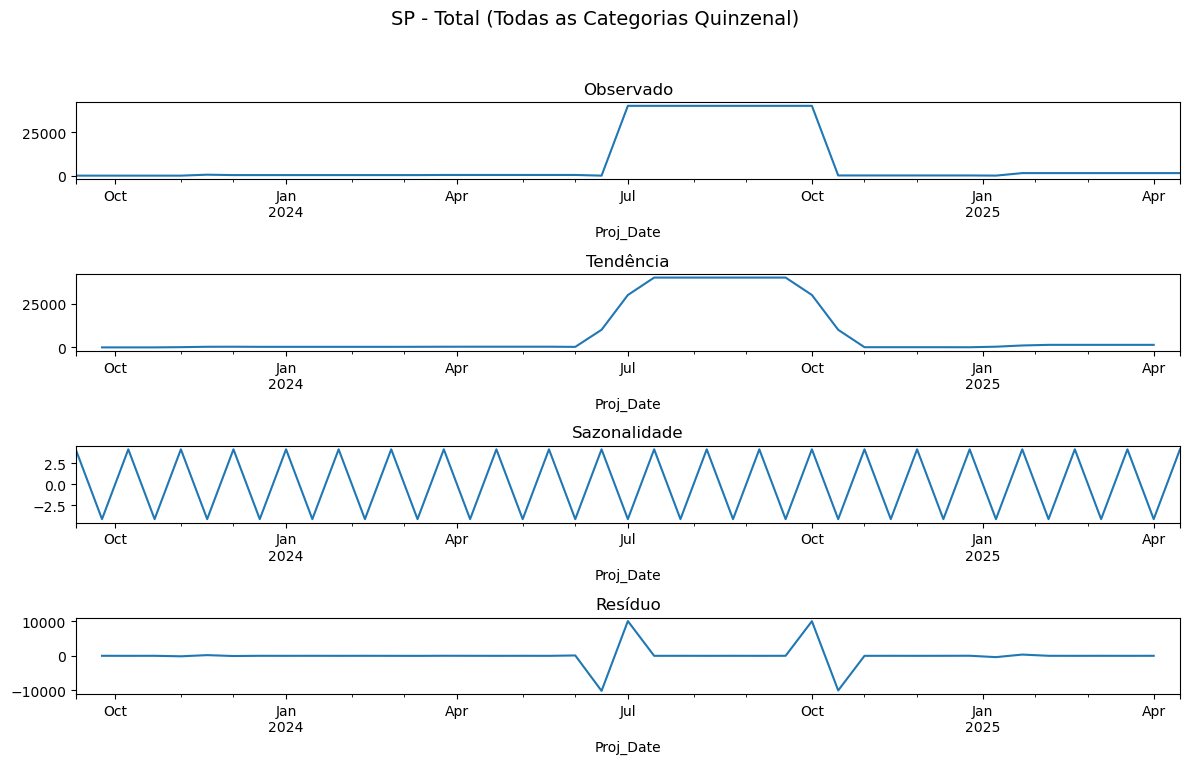

/var/folders/jx/qmnk0b3n11x14xch0hn809yh0000gn/T/ipykernel_9025/4003538793.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["BOM_Quant"] = df["BOM_Quant"].fillna(method='ffill').fillna(0)


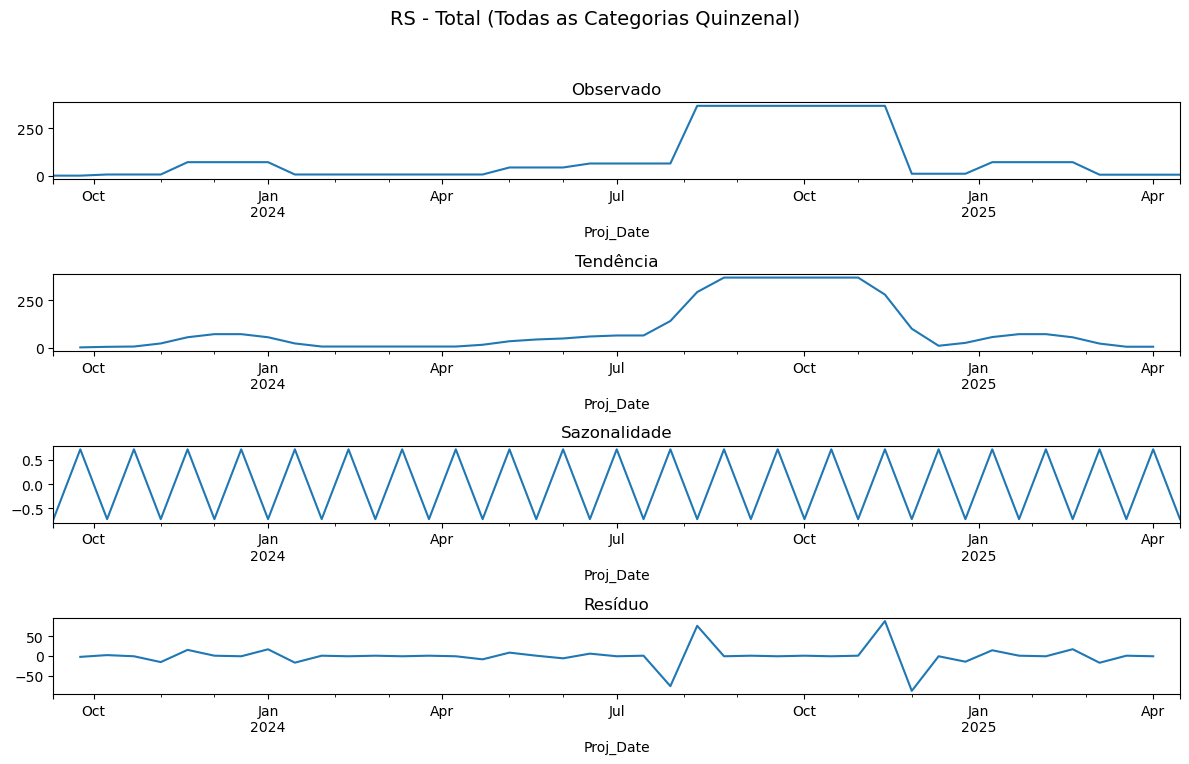

In [12]:
# Total por estado (soma das categorias quinzenais)
for estado in estados:
    dfs = []
    for categoria in categorias:
        chave = f"{estado.lower()}_{categoria.lower()}_quinzenal"
        dfs.append(bases_interpoladas[chave])
    df_total = pd.concat(dfs).groupby("Proj_Date")["BOM_Quant"].sum().reset_index()
    decompor_e_plotar(df_total, f"{estado} - Total (Todas as Categorias Quinzenal)")